# Lagos State Home Prices Prediction Model

By Jompe Emmanuel Ayomiposi, Level 3 Artificial Intelligence Project

The Machine Learning Approach used is Supervised Regression 

Supervised: It learns from data in a dataset

Regression: The label (Price), is continous

In [1]:
# Import Required Libraries

import pandas as pd                          
import numpy as np                           
import matplotlib.pyplot as plt              
import matplotlib                            
import seaborn as sns                        
import warnings                              

from sklearn.model_selection import train_test_split    
from sklearn.preprocessing import LabelEncoder          
from sklearn.ensemble import RandomForestRegressor      
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score 
import joblib                                            

warnings.filterwarnings('ignore')            

print("All Libraries imported successfully")

All Libraries imported successfully


In [2]:
# Load the Dataset

df = pd.read_csv('nigerian_properties_cleaned.csv')


print("First 5 rows of the dataset: ")
print(df.head())

print(f"\n Dataset Shape: {df.shape[0]} rows x {df.shape[1]} columns")
print("\n Column Data Types:")
print(df.dtypes)

First 5 rows of the dataset: 
   Unnamed: 0  beds  baths  toilets  state  city        price
0           0   5.0    5.0      6.0  Lagos  ajah   90000000.0
1           1   5.0    5.0      5.0  Lagos  ajah  150000000.0
2           2   4.0    4.0      4.0  Lagos  ajah  105000000.0
3           3   4.0    4.0      5.0  Lagos  ajah   85000000.0
4           4   3.0    3.0      4.0  Lagos  ajah   60000000.0

 Dataset Shape: 5500 rows x 7 columns

 Column Data Types:
Unnamed: 0      int64
beds          float64
baths         float64
toilets       float64
state          object
city           object
price         float64
dtype: object


In [3]:
# Exploratory Data Analysis (EDA)

print("Statistical Summary: ")
print(df.describe())

# Checking for missing values
print("\n Missing Values per Column: ")
print(df.isnull().sum())

# Finding unique locations in the dataset
print(f"\n Unique cities in dataset: {df['city'].nunique()}")
print(df['city'].value_counts().head(10))

Statistical Summary: 
        Unnamed: 0         beds        baths      toilets         price
count  5500.000000  5500.000000  5500.000000  5500.000000  5.500000e+03
mean   2749.500000     3.207636     3.281273     3.720182  2.275205e+08
std    1587.857571     1.955073     2.226650     2.450394  2.553928e+09
min       0.000000     0.000000     0.000000     0.000000  0.000000e+00
25%    1374.750000     2.000000     0.000000     0.000000  5.000000e+07
50%    2749.500000     4.000000     4.000000     5.000000  9.000000e+07
75%    4124.250000     5.000000     5.000000     6.000000  1.600000e+08
max    5499.000000    10.000000    10.000000    10.000000  1.800000e+11

 Missing Values per Column: 
Unnamed: 0    0
beds          0
baths         0
toilets       0
state         0
city          0
price         0
dtype: int64

 Unique cities in dataset: 6
city
lekki       1250
ikoyi       1100
ajah        1048
ikeja       1015
surulere     634
epe          453
Name: count, dtype: int64


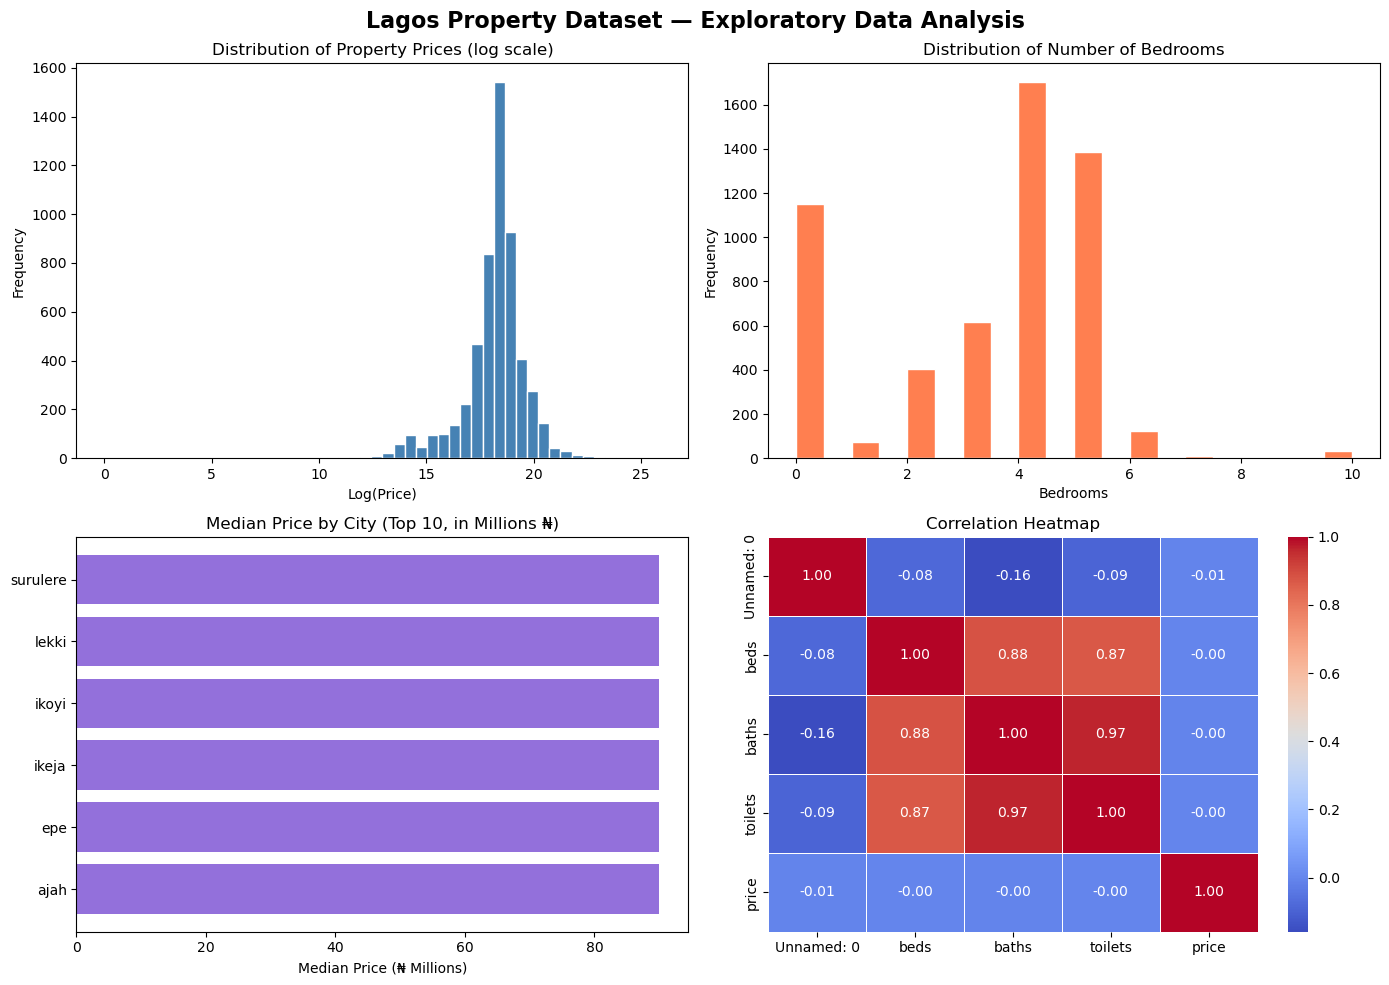

 EDA plots saved as eda_house_price.png


In [4]:
# Visualizations


fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Lagos Property Dataset — Exploratory Data Analysis', fontsize=16, fontweight='bold')

# Plot 1: Distribution of property prices
axes[0, 0].hist(np.log1p(df['price']), bins=50, color='steelblue', edgecolor='white')
axes[0, 0].set_title('Distribution of Property Prices (log scale)')
axes[0, 0].set_xlabel('Log(Price)')
axes[0, 0].set_ylabel('Frequency')

# Plot 2: Number of bedrooms distribution
axes[0, 1].hist(df['beds'].dropna(), bins=20, color='coral', edgecolor='white')
axes[0, 1].set_title('Distribution of Number of Bedrooms')
axes[0, 1].set_xlabel('Bedrooms')
axes[0, 1].set_ylabel('Frequency')

# Plot 3: Average price by city (top 10 cities)
top_cities = df.groupby('city')['price'].median().sort_values(ascending=False).head(10)
axes[1, 0].barh(top_cities.index, top_cities.values / 1e6, color='mediumpurple')
axes[1, 0].set_title('Median Price by City (Top 10, in Millions ₦)')
axes[1, 0].set_xlabel('Median Price (₦ Millions)')

# Plot 4: Correlation heatmap of numeric columns
numeric_cols = df.select_dtypes(include=np.number).columns
corr = df[numeric_cols].corr()
sns.heatmap(corr, ax=axes[1, 1], annot=True, fmt='.2f', cmap='coolwarm', linewidths=0.5)
axes[1, 1].set_title('Correlation Heatmap')

#Saving the plots
plt.tight_layout()
plt.savefig('eda_house_price.png', dpi=150, bbox_inches='tight')
plt.show()
print(" EDA plots saved as eda_house_price.png")

In [5]:
# Data Cleaning & Preprocessing


# Drop the unnecessary index column
if 'Unnamed: 0' in df.columns:
    df.drop(columns=['Unnamed: 0'], inplace=True)
    print("Dropped 'Unnamed: 0' index column")

# Remove Outliers 
Q1 = df['price'].quantile(0.25) 
Q3 = df['price'].quantile(0.75)   
IQR = Q3 - Q1                     
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

before = len(df)
df = df[(df['price'] >= lower_bound) & (df['price'] <= upper_bound)]
after = len(df)
print(f" Removed {before - after} outlier rows | Remaining: {after} rows")


# Fill missing numeric values with column median
for col in ['beds', 'baths', 'toilets']:
    df[col].fillna(df[col].median(), inplace=True)

print("All Missing values filled with column medians")
print(f"\n Cleaned dataset shape: {df.shape}")

Dropped 'Unnamed: 0' index column
 Removed 585 outlier rows | Remaining: 4915 rows
All Missing values filled with column medians

 Cleaned dataset shape: (4915, 6)


In [6]:
# Feature Engineering
# We prepare features for model training by:
#   • Encoding the 'city' categorical column as integers (Label Encoding)
#   • Defining the feature matrix X and target vector y
# State column is dropped since all records are from Lagos State.



# Label Encoder assigns each unique city a unique integer
le = LabelEncoder()
df['city_encoded'] = le.fit_transform(df['city'])

# Save the city encoder classes so Django can use the same mapping
city_classes = list(le.classes_)
print(f" Encoded {len(city_classes)} unique cities")
print("Sample mapping:", {city: i for i, city in enumerate(city_classes[:5])})



# 'state' is constant (all Lagos), 'city' replaced by 'city_encoded'
df.drop(columns=['state', 'city'], inplace=True)

# Define Feature Matrix (X) and Target Vector (y): Prices
X = df.drop(columns=['price'])    
y = df['price']                  

print(f"\n Feature matrix X shape: {X.shape}")
print(f" Target vector y shape: {y.shape}")
print(f"\n Features used: {list(X.columns)}")

 Encoded 6 unique cities
Sample mapping: {'ajah': 0, 'epe': 1, 'ikeja': 2, 'ikoyi': 3, 'lekki': 4}

 Feature matrix X shape: (4915, 4)
 Target vector y shape: (4915,)

 Features used: ['beds', 'baths', 'toilets', 'city_encoded']


In [7]:
# Train / Test Split
# We splitting the data into 80% training and 20% testing sets.


X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.20,      # 20% for testing
    random_state=42 
)

print("Data split complete:")
print(f" Training set  : {X_train.shape[0]} samples")
print(f" Testing set   : {X_test.shape[0]} samples")

Data split complete:
 Training set  : 3932 samples
 Testing set   : 983 samples


In [8]:
# Model Training (Random Forest Regressor)
'''
We train a Random Forest Regressor: an ensemble of decision trees that
reduces overfitting by averaging predictions from many trees.

Why Random Forest for Regression?
 • Handles non-linear relationships between features and price
 • Robust to outliers left in data
 • Provides built-in feature importance
 • No need for feature scaling
'''

model = RandomForestRegressor(
    n_estimators=200,    
    max_depth=None,      
    random_state=42,     
    n_jobs=-1            
)

print(" Training Random Forest Regressor... ")
model.fit(X_train, y_train)
print(" Model training complete! ")

 Training Random Forest Regressor... 
 Model training complete! 


In [ ]:
# Model Evaluation
'''
We evaluate the trained model on the test set using three key metrics:
 • MAE  (Mean Absolute Error)    — average prediction error in naira
 • RMSE (Root Mean Squared Error) — penalises large errors more
 • R²   (Coefficient of Det.)    — proportion of variance explained (0-1)
'''

# Generate predictions on the hold-out test set
y_pred = model.predict(X_test)

# Calculate evaluation metrics
mae  = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2   = r2_score(y_test, y_pred)

print("_" * 50)
print("       MODEL EVALUATION RESULTS")
print("_" * 50)
print(f"  Mean Absolute Error  (MAE)  : ₦{mae:,.0f}")
print(f"  Root Mean Sq. Error  (RMSE) : ₦{rmse:,.0f}")
print(f"  R² Score             (R²)   : {r2:.4f}  ({r2*100:.2f}% variance explained)")
print("_" * 50)

# Simple interpretation
if r2 >= 0.80:
    print("\n Excellent model fit! (R² ≥ 0.80)")
elif r2 >= 0.60:
    print("\n Good model fit! (R² ≥ 0.60)")
elif r2 >= 0.40:
    print("\n  Moderate model fit.")
else:
    print("\n Weak model fit — consider more features.")

__________________________________________________
       MODEL EVALUATION RESULTS
__________________________________________________
  Mean Absolute Error  (MAE)  : ₦46,891,965
  Root Mean Sq. Error  (RMSE) : ₦62,627,749
  R² Score             (R²)   : 0.1420  (14.20% variance explained)
__________________________________________________

 Weak model fit — consider more features.


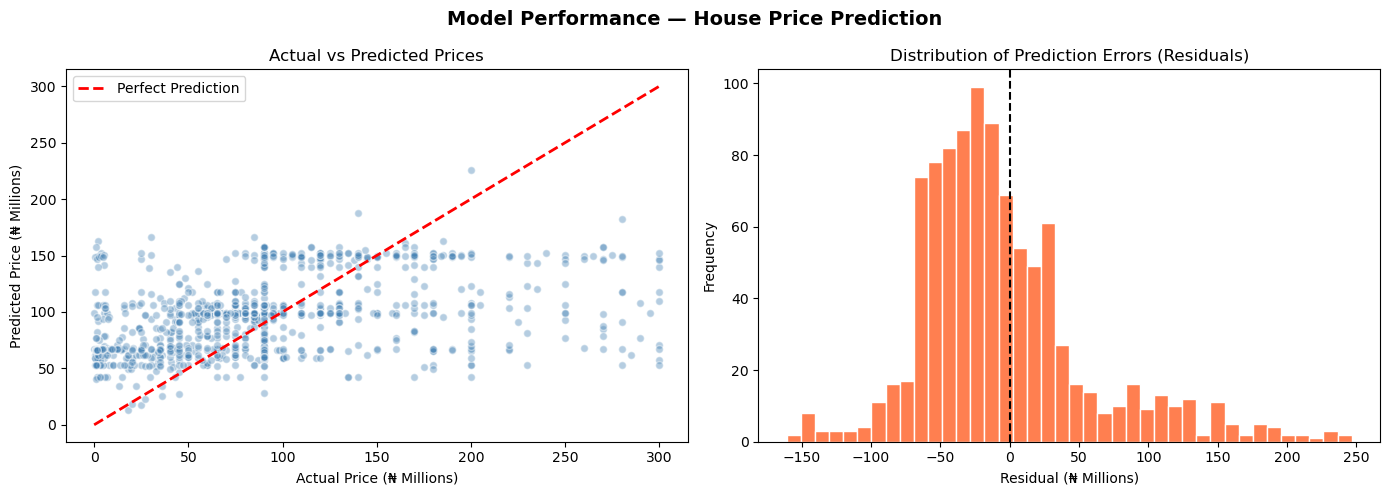

 Performance plots saved


In [14]:
# Actual vs Predicted Plot

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Model Performance — House Price Prediction', fontsize=14, fontweight='bold')

# Plot 1: Actual vs Predicted scatter
axes[0].scatter(y_test / 1e6, y_pred / 1e6, alpha=0.4, color='steelblue', edgecolors='white', s=30)
# Perfect prediction line
max_val = max(y_test.max(), y_pred.max()) / 1e6
axes[0].plot([0, max_val], [0, max_val], 'r--', lw=2, label='Perfect Prediction')
axes[0].set_xlabel('Actual Price (₦ Millions)')
axes[0].set_ylabel('Predicted Price (₦ Millions)')
axes[0].set_title('Actual vs Predicted Prices')
axes[0].legend()

# Plot 2: Residuals distribution (prediction errors)
residuals = (y_test - y_pred) / 1e6
axes[1].hist(residuals, bins=40, color='coral', edgecolor='white')
axes[1].axvline(0, color='black', linestyle='--', lw=1.5)
axes[1].set_xlabel('Residual (₦ Millions)')
axes[1].set_ylabel('Frequency')
axes[1].set_title('Distribution of Prediction Errors (Residuals)')

plt.tight_layout()
plt.savefig('model_performance_house_price.png', dpi=150, bbox_inches='tight')
plt.show()
print(" Performance plots saved")

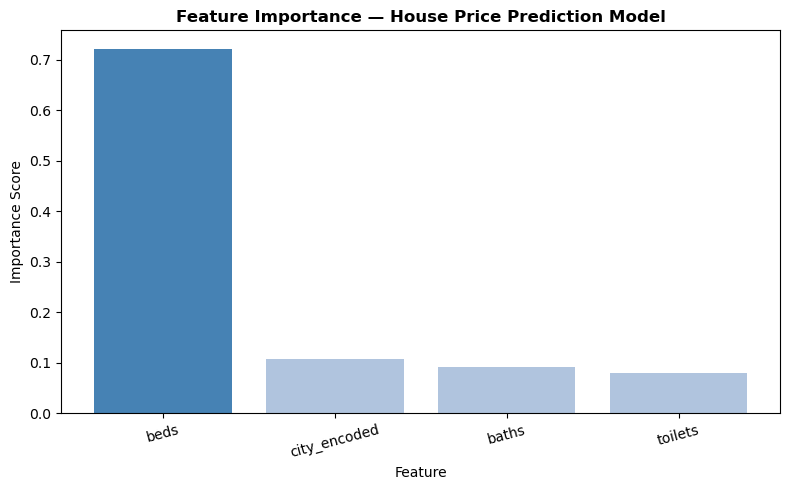


 Feature Importance Ranking:
   beds            : 0.7220
   city_encoded    : 0.1079
   baths           : 0.0907
   toilets         : 0.0794


In [15]:
# CELL 11 — Feature Importance


# Extract feature importances from the trained model
importances = model.feature_importances_
feature_names = X.columns.tolist()

# Sort features by importance (descending)
sorted_idx = np.argsort(importances)[::-1]

plt.figure(figsize=(8, 5))
colors = ['steelblue' if i == 0 else 'lightsteelblue' for i in range(len(feature_names))]
plt.bar(
    [feature_names[i] for i in sorted_idx],
    [importances[i] for i in sorted_idx],
    color=colors
)
plt.title('Feature Importance — House Price Prediction Model', fontweight='bold')
plt.xlabel('Feature')
plt.ylabel('Importance Score')
plt.xticks(rotation=15)
plt.tight_layout()
plt.savefig('feature_importance_house_price.png', dpi=150, bbox_inches='tight')
plt.show()

print("\n Feature Importance Ranking:")
for i in sorted_idx:
    print(f"   {feature_names[i]:<15} : {importances[i]:.4f}")

In [16]:
# Saving the Trained Model

import os

# Save the trained regression model
model_path = 'house_price_model.pkl'
joblib.dump(model, model_path)
print(f" Model saved to: {os.path.abspath(model_path)}")

# Save the city label encoder so Django can encode user input the same way
encoder_path = 'city_label_encoder.pkl'
joblib.dump(le, encoder_path)
print(f" City encoder saved to: {os.path.abspath(encoder_path)}")

# Save city names list for use in the Django form dropdown
city_list_path = 'city_classes.pkl'
joblib.dump(city_classes, city_list_path)
print(f" City list saved to: {os.path.abspath(city_list_path)}")

print("\n House Price Prediction Model is ready for deployment!")

 Model saved to: c:\Users\HP\Desktop\Work\SQI Course\SQI-Ai\Level 3 ML Project\Lagos State House Price Prediction\house_price_model.pkl
 City encoder saved to: c:\Users\HP\Desktop\Work\SQI Course\SQI-Ai\Level 3 ML Project\Lagos State House Price Prediction\city_label_encoder.pkl
 City list saved to: c:\Users\HP\Desktop\Work\SQI Course\SQI-Ai\Level 3 ML Project\Lagos State House Price Prediction\city_classes.pkl

 House Price Prediction Model is ready for deployment!


In [17]:
# Quick Prediction Demo


# Load the saved model from disk
loaded_model   = joblib.load('house_price_model.pkl')
loaded_encoder = joblib.load('city_label_encoder.pkl')

sample_city = 'ajah'

sample_city_encoded = loaded_encoder.transform([sample_city])[0]

# Sample Property
sample_property = pd.DataFrame({
    'beds'         : [4],
    'baths'        : [3],
    'toilets'      : [4],
    'city_encoded' : [sample_city_encoded]
})

# Predict the price
predicted_price = loaded_model.predict(sample_property)[0]

print(" Sample Prediction Demo")
print(f"   City    : {sample_city}")
print(f"   Beds    : 4  |  Baths : 3  |  Toilets : 4")
print(f"   Predicted Price: ₦{predicted_price:,.0f}")
print(f"   (~₦{predicted_price/1e6:.1f} Million)")

 Sample Prediction Demo
   City    : ajah
   Beds    : 4  |  Baths : 3  |  Toilets : 4
   Predicted Price: ₦115,720,449
   (~₦115.7 Million)
